# Portfolio Optimization

## Stock Price Analysis using Python & yFinance

This notebook fetches and visualizes historical stock price data using Yahoo Finance API via the `yfinance` library.

## 📦 Required Libraries

```python
Install & Import: 
* Numpy 
* Pandas 
* pandas data_reader
* datetime
* matplotlib
* yfinance


In [ ]:
# installations 
!pip install numpy 


In [2]:
!pip install matplotlib 

In [3]:
!pip install pandas 

In [5]:
pip install pandas_datareader 

   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ----------------------- ---------------- 2.4/4.0 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 10.4 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [lxml]
   ---------------------------------------- 0/2 [lxml]
   -------------------- ------------------- 1/2 [pandas_datareader]
   -------------------- ------------------- 1/2 [pandas_datareader]
   -------------------- ------------------- 1/2 [pandas_datareader]
   -------------------- ------------------- 1/2 [pandas_datareader]
   ---------------------------------------- 2/2 [pandas_datareader]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [6]:
# imports 
import numpy as np

In [8]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 10.4 MB/s eta 0:00:00

   ---------------------------------------- 0/7 [peewee]
   ----------- ---------------------------- 2/7 [websockets]
   ----------------- ---------------------- 3/7 [protobuf]
   ----------------- ---------------------- 3/7 [protobuf]
  Attempting uninstall: cffi
   ----------------- ---------------------- 3/7 [protobuf]
    Found existing installation: cffi 1.17.1
   ----------------- ---------------------- 3/7 [protobuf]
    Uninstalling cffi-1.17.1:
   ----------------- ---------------------- 3/7 [protobuf]
   ---------------------- ----------------- 4/7 [cffi]
   ---------------------- ----------------- 4/7 [cffi]
   ---------------------- ----------------- 4/7 [cffi]
   ---------------------- ----------------- 4/7 [cffi]
   ---------------------- ----------------- 4/7 [cffi]
   ---------------------- ----------------- 4/7 [cffi]
   ---

In [10]:
import sys
!{sys.executable} -m pip install yfinance

  Using cached yfinance-1.4.1-py2.py3-none-any.whl.metadata (6.2 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl.metadata (18 kB)
Using cached yfinance-1.4.1-py2.py3-none-any.whl (137 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl (1.7 MB)
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached peewee-4.1.0-py3-none-any.whl (155 kB)

   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
  Attempting uninstall: cffi
   ------------- -------------------------- 2/6 [


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [29]:
!pip install requests beautifulsoup4

---

### Configuration

####  Stock Selection
We analyze the following companies:

| Ticker | Company                        |
|--------|-------------------------------|
| GOOG   | Alphabet (Google)             |
| AAPL   | Apple Inc.                    |
| META   | Meta Platforms (Facebook)     |
| AMZN   | Amazon                        |
| TSLA   | Tesla                         |



```python
We will observe the daily stock prices data of year 2025.

```

In [126]:
import yfinance as yf
import datetime
import pandas as pd

# Issue selection
codes = ['GOOG', 'AAPL', 'META', 'AMZN', 'TSLA']  

# Using one year of data from 2025
start = datetime.datetime(2026, 1, 1)
end = datetime.datetime(2026, 6, 27)

# Obtain daily stock price data using yfinance
df = yf.download(codes, start=start, end=end)['Close']

# Display most recent data
display(df.tail())  # Note: tail() needs parentheses to call the function

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOG,META,TSLA
Date,,,,,
2026-06-22,297.010010,232.789993,348.779999,563.849976,405.049988
2026-06-23,294.299988,234.110001,346.079987,562.200012,381.609985
2026-06-24,293.079987,234.270004,345.040009,557.669983,375.529999
2026-06-25,275.149994,227.009995,342.190002,542.869995,375.119995
2026-06-26,283.779999,232.690002,334.690002,550.250000,379.709991


## 📊 Plotting All Stocks

<Axes: xlabel='Date'>

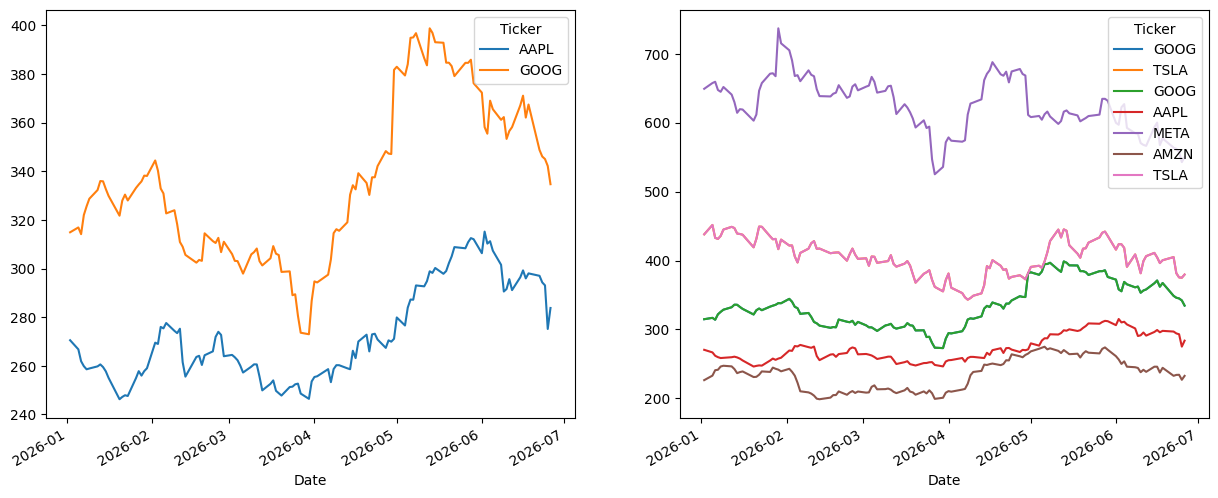

In [127]:
# plot the stock price
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))


df.loc[:, ['AAPL', 'GOOG']].plot(ax=axes[0])
df.loc[:, ['GOOG', 'TSLA']].plot(ax=axes[1])
df.loc[:, ['GOOG', 'AAPL', 'META', 'AMZN', 'TSLA']].plot(ax=axes[1])

## Daily Returns Calculation

Daily return measures the _percentage change_ in stock price from one day to the next.

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}} \times 100$$

Where:
- $P_t$ = today's closing price  
- $P_{t-1}$ = yesterday's closing price  
- $r_t$ = daily return on day $t$


In [129]:
daily_return = df.pct_change()
display(daily_return.tail())

Ticker,AAPL,AMZN,GOOG,META,TSLA
Date,,,,,
2026-06-22,-0.003356,-0.047465,-0.050835,-0.023163,0.011386
2026-06-23,-0.009124,0.005670,-0.007741,-0.002926,-0.057869
2026-06-24,-0.004145,0.000683,-0.003005,-0.008058,-0.015932
2026-06-25,-0.061178,-0.030990,-0.008260,-0.026539,-0.001092
2026-06-26,0.031365,0.025021,-0.021918,0.013594,0.012236


##  Expected Returns

The expected return $\vec{R}$ for each stock is calculated as the arithmetic mean of historical daily returns.

_Formula_:
$$\vec{R} = \frac{1}{T} \sum_{t=1}^{T} \vec{y_t}$$

Where:
- $\vec{R}$ = expected return vector (one value per stock)
- $T$ = total number of trading days
- $\vec{y_t}$ = daily return of all stocks on day $t$


In [130]:
expected_return = daily_return.dropna(how='all').mean() * 30 # multiplied by 30 means monthly returns; 
print(expected_return) 
                                    

Ticker
AAPL    0.015988
AMZN    0.012695
GOOG    0.020762
META   -0.031677
TSLA   -0.026027
dtype: float64


### Variance/Covariance Matrix
The sample unbiased variance/covariance matrix $\sum$ of the returns is defined by 

$$ \sum = \frac{1} {T -1} \sum_{t=1}^{T} (\vec{y_t} - \vec{R}) (\vec{y_t} - \vec{R})^T $$

In [131]:
cov = daily_return.dropna(how='all').cov() * 30
display(cov)

Ticker,AAPL,AMZN,GOOG,META,TSLA
Ticker,,,,,
AAPL,0.008048,0.003250,0.002300,0.003630,0.003783
AMZN,0.003250,0.011987,0.006353,0.008425,0.005181
GOOG,0.002300,0.006353,0.011310,0.004621,0.004521
META,0.003630,0.008425,0.004621,0.019516,0.006557
TSLA,0.003783,0.005181,0.004521,0.006557,0.019526


##  Portfolio Optimization

#### What is a Portfolio?
A portfolio is represented by a weight vector:

$$\vec{w} = (w_0, w_1, w_2, w_3)^T$$

> Example: $\vec{w} = (1, 0, 0, 0)$ means 100% invested in Google

<h5> Goal: Minimize Risk, Fix Return</h5>

$$\min_{\vec{w}} \frac{1}{2} \vec{w}^T \Sigma \vec{w}$$

$$s.t. \quad \vec{R}^T \vec{w} = \mu, \quad \vec{1}^T \vec{w} = 1$$

In simple words:
- Minimize the variance (risk) of the portfolio
- Target return must equal $\mu$
- Weights must sum to 1 (invest 100% of your money)

> This approach is called _Markowitz Mean-Variance Method_ a foundation of modern financial engineering.

<h5>How to Solve It? </h5>
Using the Lagrange Multiplier Method, the problem reduces to a simple linear equation:

$$W \begin{pmatrix} \eta \\ \theta \\ \vec{w} \end{pmatrix} = \begin{pmatrix} \mu \\ 1 \\ \vec{0} \end{pmatrix}, \quad W = \begin{pmatrix} 0 & 0 & \vec{R}^T \\ 0 & 0 & \vec{1}^T \\ \vec{R} & \vec{1} & \Sigma \end{pmatrix} \tag{1}$$

Where:
- $\eta, \theta$ = _Lagrange multiplier_ parameters
- $W$ = system matrix combining constraints and covariance

<h5>Why Does This Matter? </h5>
Solving equation $(1)$ gives us the optimal portfolio weights $\vec{w}$.

> This is now a linear equation problem exactly where the _HHL Quantum Algorithm_ can be applied to solve it exponentially faster!

<h3> Creating the matrix W </h3>

In [132]:
n = len(expected_return)  

R = expected_return.values
pi = np.ones(n)          
S = cov.values

r1 = np.append(np.zeros(2), R).reshape(1, -1)
r2 = np.append(np.zeros(2), pi).reshape(1, -1)  
r3 = np.concatenate([R.reshape(-1, 1), pi.reshape(-1, 1), S], axis=1)

W = np.concatenate([r1, r2, r3])

np.set_printoptions(linewidth=200)
print(W)

[[ 0.          0.          0.01598793  0.01269499  0.02076225 -0.03167709 -0.02602716]
 [ 0.          0.          1.          1.          1.          1.          1.        ]
 [ 0.01598793  1.          0.00804832  0.00324994  0.0023      0.0036298   0.00378307]
 [ 0.01269499  1.          0.00324994  0.01198682  0.00635345  0.00842532  0.00518065]
 [ 0.02076225  1.          0.0023      0.00635345  0.01131014  0.00462074  0.00452104]
 [-0.03167709  1.          0.0036298   0.00842532  0.00462074  0.01951556  0.00655718]
 [-0.02602716  1.          0.00378307  0.00518065  0.00452104  0.00655718  0.01952607]]


In [133]:
# check eigenvalue of W --> fits in [-pi, pi]
print(np.linalg.eigh(W)[0])

[-2.21938408 -0.04492516  0.00467491  0.00757387  0.01353376  0.05600307  2.25291053]


### Creating the right-rand side vector:

In [134]:
# portfolio return 
mu = 0.1 

xi = 1.0 

mu_xi_0 = np.append(np.array([mu, xi]), np.zeros_like(R)) 
print(mu_xi_0)

[0.1 1.  0.  0.  0.  0.  0. ]


 ### Extend the matrix so that it can be handled by a quantum system
Since W is 8-dimensional, so it is computable in a quantum system with 3 qubit 

In [135]:
nbit = 3 # num of bit used for state

N = 2**nbit
W_enl = np.zeros((N, N)) # enl stands for enlarged 
W_enl[:W.shape[0], :W.shape[1]] = W.copy()
mu_xi_0_enl = np.zeros(N)
mu_xi_0_enl[:len(mu_xi_0)] = mu_xi_0.copy()

Now, we can solve the simultaneous equation

## Preparing for HHL Algorithm

To solve the linear equation (1) using HHL, we need three helper functions:

1. `input_state_gate` — converts classical data $x$ into a quantum state $|0\cdots0\rangle \rightarrow \sum_i x_i |i\rangle$ (implemented as a non-unitary gate on simulator)

2. `CPhaseGate` — returns a controlled phase gate

3. `QFT_gate` — returns a quantum Fourier transform gate

In [136]:
# Install Qulacs
!pip install qulacs

In [137]:
import sys
!{sys.executable} -m pip install wurlitzer


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [138]:
!pip install qulacs wurlitzer

In [87]:
import sys
!{sys.executable} -m pip install qulacs


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/650.9 kB ? eta -:--:--
   ---------------------------------------- 650.9/650.9 kB 6.3 MB/s eta 0:00:00


In [139]:
import numpy as np
from qulacs import QuantumCircuit, QuantumState, gate
from qulacs.gate import merge, Identity, H, SWAP

def input_state_gate(start_bit, end_bit, vec):
    nbit = end_bit - start_bit + 1
    assert vec.size == 2**nbit
    mat_0tox = np.eye(vec.size, dtype = complex)
    mat_0tox[:, 0] = vec
    return gate.DenseMatrix(np.arange(start_bit, end_bit+1), mat_0tox)

def CPhaseGate(target, control, angle):
    CPhaseGate = gate.DenseMatrix(target, np.array([[1,0], [0, np.cos(angle)+1.j*np.sin(angle)]]))
    CPhaseGate.add_control_qubit(control, 1)
    return CPhaseGate

def QFT_gate(start_bit, end_bit, Inverse = False):
    g = Identity(start_bit)         # creating empty gate
    n = end_bit - start_bit + 1        # size of QFT 

    for target in range(end_bit, start_bit-1, -1):
       gate = merge(gate, H(target))   ## 1/sqrt(2) |0> + exp(i * 2pi*0.j_{target}) |1>

    for control in range(start_bit, target):
       gate = merge(gate, CPhaseGate(target, control, (-1)**Inverse * 2.*np.pi/2**(target-control+1)))

   ## perform SWAP between (start_bit + s)-th bit and (end_bit - s)-th bit
    for s in range(n//2):               ## s runs 0 to n//2-1
       gate = merge(gate, SWAP(start_bit + s, end_bit - s))

   ## return final circuit
    return gate



## HHL Algorithm Parameters
- `reg_nbit = 7` — clock register size controlling phase estimation precision
- `scale_fac = 1` — matrix W is used as-is without scaling
- `c` — set to half the smallest nonzero value representable by `reg_nbit` bits

In [140]:
# num of registers used for phase estimation 
reg_nbit = 7

# Factor to scale w_enl
scale_fac = 1
W_enl_scaled = scale_fac * W_enl

# Minimum value to be assumed as an eigenvalue of W_enl_scaled
# In this case projection succeeds 100%, we set the value as a constant multiple of the minimum valuethat can be represented by the register. 
C = 0.5 * (2 * np.pi * (1./2**(reg_nbit)))



## HHL Algorithm Implementation

Since we use the qulacs simulator, several simplifications are made:

- Input state $|b\rangle$ preparation is simplified
- $e^{iA}$ in quantum phase estimation is computed via classical diagonalization of $A$
- Control rotation gate (inverse) is implemented classically
- Only measurement results where auxiliary bit $|0\rangle_S = 0$ are kept

In [141]:
def QFT_gate(start_bit, end_bit, Inverse=False):
    g = Identity(start_bit)        # Fixed: renamed 'gate' to 'g' to avoid conflict with imported 'gate' module
    n = end_bit - start_bit + 1
    for target in range(end_bit, start_bit-1, -1):
        g = merge(g, H(target))
        for control in range(start_bit, target):
            g = merge(g, CPhaseGate(target, control, (-1)**Inverse * 2.*np.pi/2**(target-control+1)))
    for s in range(n//2):
        g = merge(g, SWAP(start_bit + s, end_bit - s))
    return g

In [142]:
from functools import reduce

# Diagonalization: AP = PD <-> A = P*D*P^dag
D, P = np.linalg.eigh(W_enl_scaled)

total_qubits = nbit + reg_nbit + 1
total_circuit = QuantumCircuit(total_qubits)
state = QuantumState(total_qubits)
state.set_zero_state()

# Input state preparation
b_gate = input_state_gate(0, nbit-1, mu_xi_0_enl)
total_circuit.add_gate(b_gate)

# Apply Hadamard to clock register
for register in range(nbit, nbit+reg_nbit):
    total_circuit.add_H_gate(register)

# Controlled unitary (forward)
for register in range(nbit, nbit+reg_nbit):          
    U_mat = reduce(np.dot, [P, np.diag(np.exp(1.j * D * (2**(register-nbit)))), P.T.conj()])  
    U_gate = gate.DenseMatrix(np.arange(nbit), U_mat)
    U_gate.add_control_qubit(register, 1)
    total_circuit.add_gate(U_gate)

# Inverse QFT
total_circuit.add_gate(QFT_gate(nbit, nbit+reg_nbit-1, Inverse=True))  

# Controlled rotation gate
condrot_mat = np.zeros((2**(reg_nbit+1), 2**(reg_nbit+1)), dtype=complex)
for index in range(2**reg_nbit):
    lam = 2 * np.pi * (float(index) / 2**(reg_nbit))
    index_0 = index
    index_1 = index + 2**reg_nbit
    if lam >= C:                                     
        if lam >= np.pi:
            lam = lam - 2*np.pi
        condrot_mat[index_0, index_0] =   C / lam
        condrot_mat[index_1, index_0] =   np.sqrt(1 - C**2/lam**2)
        condrot_mat[index_0, index_1] = - np.sqrt(1 - C**2/lam**2)
        condrot_mat[index_1, index_1] =    C/ lam
    else:
        condrot_mat[index_0, index_0] = 1.
        condrot_mat[index_1, index_1] = 1.

condrot_gate = gate.DenseMatrix(np.arange(nbit, nbit+reg_nbit+1), condrot_mat)
total_circuit.add_gate(condrot_gate)

# Forward QFT
total_circuit.add_gate(QFT_gate(nbit, nbit+reg_nbit-1, Inverse=False))  

# Controlled unitary (inverse)
for register in range(nbit, nbit+reg_nbit):
    U_mat = reduce(np.dot, [P, np.diag(np.exp(-1.j * D * (2**(register-nbit)))), P.T.conj()])
    U_gate = gate.DenseMatrix(np.arange(nbit), U_mat)
    U_gate.add_control_qubit(register, 1)
    total_circuit.add_gate(U_gate)

# Uncompute Hadamard
for register in range(nbit, nbit+reg_nbit):
    total_circuit.add_H_gate(register)

# Project auxiliary qubit
total_circuit.add_P0_gate(nbit+reg_nbit)            

# Run circuit and extract result
total_circuit.update_quantum_state(state)
result = state.get_vector()[:2**nbit].real
x_HHL = result / C * scale_fac                       

In [143]:
x_exact = np.linalg.lstsq(W_enl, mu_xi_0_enl, rcond=0)[0]

print("HHL: ", x_HHL)
print("exact: ", x_exact)
rel_error = np.linalg.norm(x_HHL - x_exact) / np.linalg.norm(x_exact)
print("real_error:", rel_error)

HHL:  [-0.14813404 -0.00117251  0.97632839  0.76448685  1.02896258 -1.02538158 -0.74619656  0.        ]
exact:  [-3.84489058e-01 -1.06828362e-03  1.16054143e+00  8.18309534e-01  8.42122570e-01 -1.09342692e+00 -7.27546615e-01  0.00000000e+00]
real_error: 0.16980067376531652


#### If we take out only the actual weighting part 

In [144]:
# Reset everything from scratch
codes = ['GOOG', 'AAPL', 'META', 'AMZN']
df = yf.download(codes, start=start, end=end)['Close']

print("df shape:", df.shape)
print("df columns:", df.columns.tolist())

[*********************100%***********************]  4 of 4 completed

df shape: (121, 4)
df columns: ['AAPL', 'AMZN', 'GOOG', 'META']


In [145]:
w_opt_HHL = x_HHL[2:6]
w_opt_exact = x_exact[2:6]
w_opt = pd.DataFrame(
    np.vstack([w_opt_exact, w_opt_HHL]).T, 
    index=codes, columns=['exact', 'HHL'])
w_opt

,exact,HHL
GOOG,1.160541,0.976328
AAPL,0.818310,0.764487
META,0.842123,1.028963
AMZN,-1.093427,-1.025382


<Axes: >

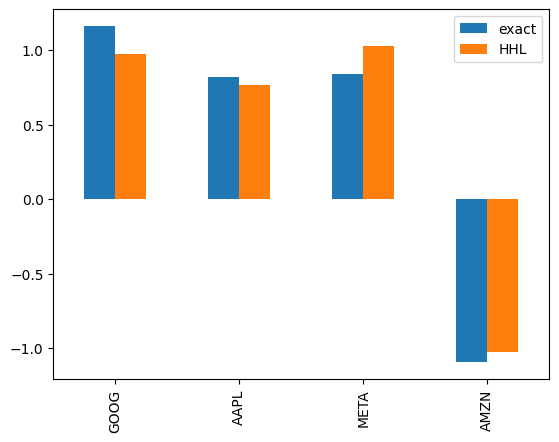

In [146]:
w_opt.plot.bar()

### Back Testing

In [147]:
import yfinance as yf
import datetime

codes = ['GOOG', 'AAPL', 'META', 'AMZN']

# 10 years of data
start = datetime.datetime(2025, 1, 30)
end   = datetime.datetime(2026, 1, 30)

# Fetch data using yfinance
df2025 = yf.download(codes, start=start, end=end)['Close']

display(df2025.tail())

[*********************100%***********************]  3 of 4 completed


Ticker,AAPL,AMZN,GOOG,META
Date,,,,
2026-01-23,247.580017,239.160004,328.001404,657.587036
2026-01-26,254.936356,238.419998,333.154663,671.162720
2026-01-27,257.791016,244.679993,334.562805,671.771667
2026-01-28,255.964462,243.009995,335.841156,667.539185
2026-01-29,257.801025,241.729996,338.218048,736.995361


<Axes: xlabel='Date'>

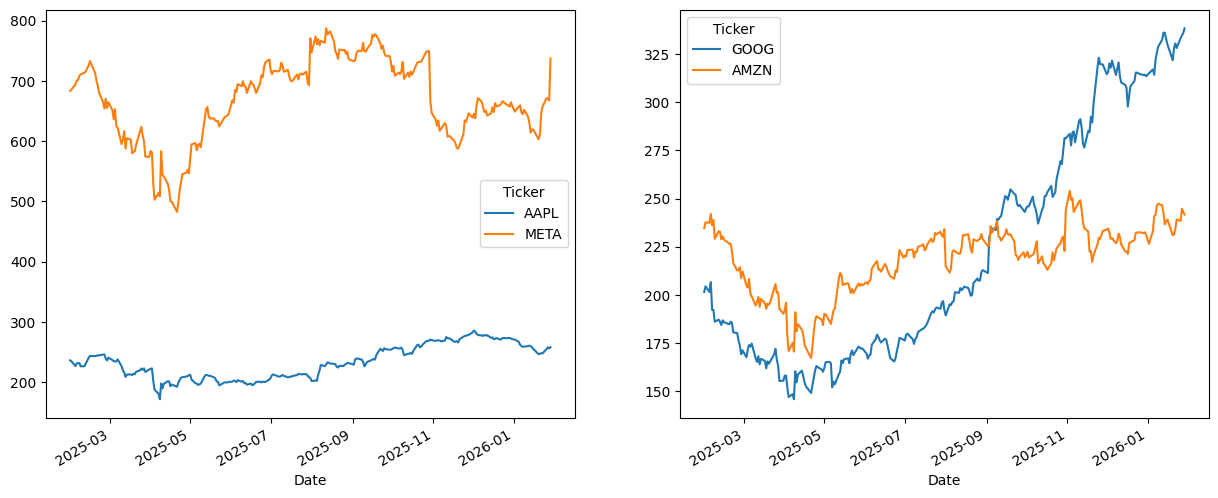

In [148]:
## Plot the stock price
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
df2025.loc[:,['AAPL', 'META']].plot(ax=axes[0])
df2025.loc[:,['GOOG', 'AMZN']].plot(ax=axes[1])


In [149]:
# changes in portfolio asset values 
pf_value = df2025.dot(w_opt)
pf_value.head()

,exact,HHL
Date,,
2025-01-30,746.261675,840.115223
2025-01-31,746.900670,840.907155
2025-02-03,744.209227,840.707203
2025-02-04,754.523587,851.403232
2025-02-05,744.628587,843.892295


In [150]:
# Normalize by the first value using iloc for positional indexing
pf_value.exact = pf_value.exact / pf_value.exact.iloc[0]
pf_value.HHL   = pf_value.HHL   / pf_value.HHL.iloc[0]

print(pf_value.tail())

               exact       HHL
Date                          
2026-01-23  1.173209  1.119978
2026-01-26  1.205694  1.150192
2026-01-27  1.202529  1.147531
2026-01-28  1.200185  1.144209
2026-01-29  1.286149  1.235274


<Axes: xlabel='Date'>

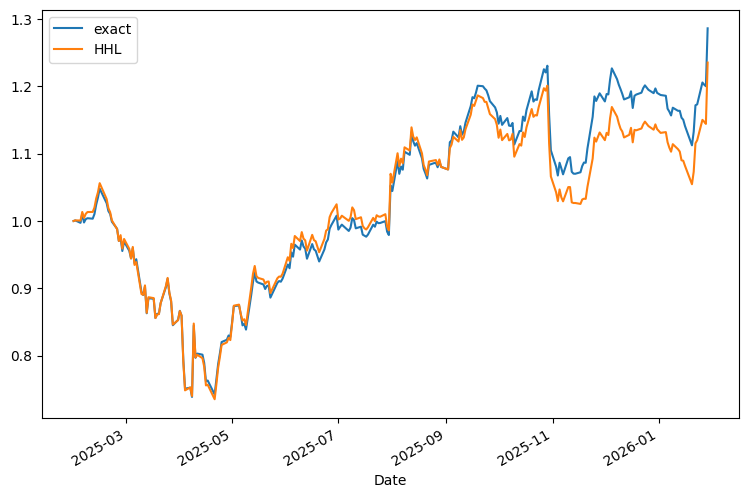

In [151]:
pf_value.plot(figsize=(9, 6))

In [152]:
pf_value.pct_change().std() * np.sqrt(252)

exact    0.325713
HHL      0.337924
dtype: float64

## References

[1] P. Rebentrost and S. Lloyd, "Quantum computational finance: quantum algorithm for portfolio optimization", *arXiv:1811.03975*, 2018. [https://arxiv.org/abs/1811.03975](https://arxiv.org/abs/1811.03975)